# Reconstrucción de energía de los rayos gamma detectados por HAWC
Por: Josué Cuauhtémoc Bucio Rivera \
El observatorio HAWC (High-Altitude Water Cherenkov) es un instrumento que detecta, entre otras cosas, rayos gamma de muy altas energías. Los rayos gamma, al entrar en contacto con la atmósfera, generan cascadas de partículas que HAWC detecta en sus tanques. Un reto importante al que nos enfrentamos es determinar la energía original a partir de los parámetros que HAWC puede medir; este problema es conocido como reconstrucción de energía.

Al ser un problema relevante, ya existen modelos de reconstrucción estadísticos como GP, o incluso modelos de redes neuronales, como el implementado en [1] (por S. S. Marinelli y J. A. Goodman, ICRC 2017), en el que se utiliza un conjunto de características de la cascada para el entrenamiento.

## Objetivo
El objetivo de este proyecto es desarrollar una red neuronal para la reconstruccion de energia de los rayos gamma detectados por HAWC y comparar el modelo desarrollado con los modelos ya existentes.

Para el desarrollo del proyecto se utilizará un conjunto de datos proporcionado, rico en variables descriptivas de las cascadas [2], con el objetivo de predecir la variable mc.logEnergy, comparando nuestros resultados con los estimadores existentes como rec.logNNEnergy y rec.logGP.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from matplotlib import colors
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

I0000 00:00:1790550341.948994   48560 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790550341.954108   48560 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790550342.580796   48560 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790550344.629951   48560 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
df = pd.read_csv('_subsample_1000000_subsamples_filtered_selectedcols.csv')

## Muestreo de datos. 
Se utilizaron 1,000,000 datos de diferentes caracterísiticas recabados por HAWC de rayos gamma para entrenar a la red neuronal. Los datos de la energía "verdadera" están dados por simulaciones de Monte-Carlo. 

In [3]:
#Caracteristicas sugeridas por el articulo [1]
indices_features = [df.columns.get_loc('rec.zenithAngle'), df.columns.get_loc('rec.coreX'), df.columns.get_loc('rec.coreY'),
          df.columns.get_loc('rec.nHit'), df.columns.get_loc('rec.logNPE'), df.columns.get_loc('rec.logMaxPE'),
          df.columns.get_loc('rec.CxPE40'), df.columns.get_loc('rec.LDFAge'), df.columns.get_loc('rec.PINC'),
          df.columns.get_loc('rec.fAnnulusCharge0'), df.columns.get_loc('rec.fAnnulusCharge1'), df.columns.get_loc('rec.fAnnulusCharge2'),
          df.columns.get_loc('rec.fAnnulusCharge3'), df.columns.get_loc('rec.fAnnulusCharge4'), df.columns.get_loc('rec.fAnnulusCharge5'),
          df.columns.get_loc('rec.fAnnulusCharge6'), df.columns.get_loc('rec.fAnnulusCharge7'), df.columns.get_loc('rec.fAnnulusCharge8')]

indice_prediccion = df.columns.get_loc('mc.logEnergy')
indice_modeloAlterno = df.columns.get_loc('rec.logNNEnergy')
indice_modelo_GP = df.columns.get_loc("rec.logGP")

In [4]:
corr = df.corr()
mask = (corr.abs() > 0.5) & (corr != 1.0)
filtered_corr = corr.where(mask).dropna(how='all').dropna(axis=1, how='all')

In [5]:
print(filtered_corr['mc.logEnergy'])

mc.radiusWeight           0.524339
mc.logEnergy                   NaN
rec.nChAvail                   NaN
rec.nHitTot               0.561095
rec.nHit                  0.560905
rec.nHitSP10                   NaN
rec.nHitSP20              0.501344
rec.nTankAvail                 NaN
rec.nTankHitTot           0.643156
rec.nTankHit              0.637678
rec.windowHits                 NaN
rec.logMaxPE                   NaN
rec.logNPE                     NaN
rec.CxPE40                     NaN
rec.zenithAngle                NaN
rec.azimuthAngle               NaN
rec.coreX                      NaN
rec.coreY                      NaN
rec.coreFiduScale              NaN
rec.planeNDOF             0.516270
rec.planeChi2             0.561797
rec.fAnnulusCharge0            NaN
rec.fAnnulusCharge1            NaN
rec.chargeFiduScale50          NaN
rec.chargeFiduScale70          NaN
rec.chargeFiduScale90          NaN
rec.LDFAge                     NaN
rec.LDFAmp                     NaN
rec.LDFChi2         

In [6]:
#Caracteristicas sugeridas por el articulo [1] mas caracteristicas agregadas por su correlacion
indices_features_corr = [df.columns.get_loc('rec.zenithAngle'), df.columns.get_loc('rec.coreX'), df.columns.get_loc('rec.coreY'),
          df.columns.get_loc('rec.nHit'), df.columns.get_loc('rec.logNPE'), df.columns.get_loc('rec.logMaxPE'),
          df.columns.get_loc('rec.CxPE40'), df.columns.get_loc('rec.LDFAge'), df.columns.get_loc('rec.PINC'),
          df.columns.get_loc('rec.fAnnulusCharge0'), df.columns.get_loc('rec.fAnnulusCharge1'), df.columns.get_loc('rec.fAnnulusCharge2'),
          df.columns.get_loc('rec.fAnnulusCharge3'), df.columns.get_loc('rec.fAnnulusCharge4'), df.columns.get_loc('rec.fAnnulusCharge5'),
          df.columns.get_loc('rec.fAnnulusCharge6'), df.columns.get_loc('rec.fAnnulusCharge7'), df.columns.get_loc('rec.fAnnulusCharge8'),
          df.columns.get_loc('rec.planeChi2'), df.columns.get_loc('rec.planeNDOF'), df.columns.get_loc('rec.nTankHit'),
          df.columns.get_loc('rec.nTankHitTot'), df.columns.get_loc('rec.nHitTot')]

In [7]:
features = df.iloc[:, indices_features].values
cos_zenith_f = np.cos(features[:, 0]).reshape(-1, 1)
features = np.hstack((features, cos_zenith_f ))
features[:, 0] = np.sin(features[:, 0])

features_corr = df.iloc[:, indices_features_corr].values
cos_zenith_fc = np.cos(features_corr[:, 0]).reshape(-1, 1)
features_corr = np.hstack((features_corr, cos_zenith_fc ))
features_corr[:, 0] = np.sin(features_corr[:, 0])

prediccion = df.iloc[:, indice_prediccion].values

In [8]:
#Normalizacion y callbacks
scaler_base = StandardScaler()
scaler_corr = StandardScaler()
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint1 = ModelCheckpoint('mejor_modelo1.h5', monitor='val_loss', save_best_only=True, mode='min')
checkpoint2 = ModelCheckpoint('mejor_modelo2.h5', monitor='val_loss', save_best_only=True, mode='min')
checkpoint3 = ModelCheckpoint('mejor_modelo3.h5', monitor='val_loss', save_best_only=True, mode='min')
checkpoint4 = ModelCheckpoint('mejor_modelo4.h5', monitor='val_loss', save_best_only=True, mode='min')

In [9]:
all_indices = np.arange(len(df))
#Esto nos permitira usar los mismos indices para todos los modelos
train_val_indices, final_test_indices = train_test_split(all_indices, test_size=0.2, random_state=42)

#Los datos de validacion para todos los modelos
final_features_base_test = features[final_test_indices]
final_features_corr_test = features_corr[final_test_indices]
final_target_test = prediccion[final_test_indices]

#Datos a dividir en entrenamiento y validacion para cada modelo
features_corr_train_val = features_corr[train_val_indices]
features_base_train_val = features[train_val_indices]
target_train_val = prediccion[train_val_indices]

#Escalamiento de los features para los modelos sin correlacionar
features_base_train_val_scaled = scaler_base.fit_transform(features_base_train_val)
final_features_base_test_scaled = scaler_base.transform(final_features_base_test)

#Particiones de los modelos sin correlacionar
x_train_base, x_val_base, y_train_base, y_val_base = train_test_split(
    features_base_train_val_scaled, target_train_val, test_size=0.125, random_state=42)

#Escalamiento de los features correlacionados
features_corr_train_val_scaled = scaler_corr.fit_transform(features_corr_train_val)
final_features_corr_test_scaled = scaler_corr.transform(final_features_corr_test)

#Particion del modelo correlacionado
x_train_corr, x_val_corr, y_train_corr, y_val_corr = train_test_split(
    features_corr_train_val_scaled, target_train_val, test_size=0.125, random_state=42)

In [10]:
#Separacion datos de entremiento y prueba
longitud = len(x_train_corr)

# Proceso de la definición de la topología de la red.
Durante el proceso de construcción se intentó lo siguiente: \
-Aumentar el número de neuronas en las capas ocultas o el número de capas ocultas; se encontró que después de alrededor de 128 neuronas y 3 capas ocultas el redimiento no mejora, debajo de estos valores el rendimiento si empeora. \
-Uso de dropouts; el uso de dropouts para este problema fue innecesario ya que como se observará en los esquemas el rendimiento permance igual e incluso empeora, en el modelo final no fue implementado.\
-Uso de optimizadores; en este caso se intentó con SGD, RMSprop, adagrad, adadelta, nadam y adam, solo los últimos dos mejoraban el rendimiento en espcial adam, por eso fue empleado en el último modelo. \
-Uso de regularizadores; se intentó mejorar el rendimiento con L1 y L2 y combinaciones de ellos al final se encontró que el uso de L2 en la segunda capa oculta mejoraba el rendimiento y se implementó para el modelo final. 
# Callbacks.
Aquí fueron de suma importancia los callbacks, con especial mención para 'EarlyStopping', ya que los archivos eran muy pesados no se podía correr muchas veces. Se solventó con el uso de 'EarlyStopping'. Por otro lado, también se usó 'ModelCheckpoint', pero como se observa en las gráficas, los últimos modelos —que son los mejores— son muy similares entre sí; su uso no es fundamental.


# Modelo 1

In [11]:
model_1 = Sequential([
Dense(64, activation='relu', input_shape=(19,)),
Dense(64, activation='relu'),
Dense(1)])

/home/erenkurosaki/.local/lib/python3.14/site-packages/keras/src/layers/core/dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790550368.129624   48560 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



In [12]:
model_1.compile(loss='mean_squared_error', metrics=['mae'])

In [13]:
history_1 = model_1.fit(x_train_base, y_train_base,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_base, y_val_base),
                    callbacks=[early_stop, checkpoint1])

Epoch 1/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2735 - mae: 0.3645

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2735 - mae: 0.3645 - val_loss: 0.1696 - val_mae: 0.2979
Epoch 2/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1645 - mae: 0.2944

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.1645 - mae: 0.2944 - val_loss: 0.1632 - val_mae: 0.2961
Epoch 3/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1544 - mae: 0.2851

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1544 - mae: 0.2851 - val_loss: 0.1578 - val_mae: 0.2917
Epoch 4/200
1337/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1490 - mae: 0.2801

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1490 - mae: 0.2800 - val_loss: 0.1531 - val_mae: 0.2885
Epoch 5/200
1344/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1456 - mae: 0.2768

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1281 - mae: 0.2589 - val_loss: 0.1333 - val_mae: 0.2663
Epoch 63/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1281 - mae: 0.2588 - val_loss: 0.1334 - val_mae: 0.2665
Epoch 64/200
1345/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1280 - mae: 0.2587

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1280 - mae: 0.2587 - val_loss: 0.1333 - val_mae: 0.2663
Epoch 65/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1280 - mae: 0.2587 - val_loss: 0.1334 - val_mae: 0.2663
Epoch 66/200
1365/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1279 - mae: 0.2586

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1279 - mae: 0.2586 - val_loss: 0.1332 - val_mae: 0.2661
Epoch 67/200
1354/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1279 - mae: 0.2586

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1279 - mae: 0.2586 - val_loss: 0.1331 - val_mae: 0.2659
Epoch 68/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1278 - mae: 0.2585 - val_loss: 0.1332 - val_mae: 0.2662
Epoch 69/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1278 - mae: 0.2585 - val_loss: 0.1332 - val_mae: 0.2662
Epoch 70/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1277 - mae: 0.2585 - val_loss: 0.1332 - val_mae: 0.2662
Epoch 71/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1277 - mae: 0.2584 - val_loss: 0.1331 - val_mae: 0.2662
Epoch 72/200
1363/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1277 - mae: 0.2584

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1276 - mae: 0.2584 - val_loss: 0.1329 - val_mae: 0.2656
Epoch 73/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1276 - mae: 0.2583 - val_loss: 0.1331 - val_mae: 0.2661
Epoch 74/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1276 - mae: 0.2583 - val_loss: 0.1331 - val_mae: 0.2660
Epoch 75/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1275 - mae: 0.2583 - val_loss: 0.1330 - val_mae: 0.2659
Epoch 76/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1275 - mae: 0.2582 - val_loss: 0.1330 - val_mae: 0.2660
Epoch 77/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1275 - mae: 0.2582 - val_loss: 0.1330 - val_mae: 0.2659


In [14]:
model_1 = load_model('mejor_modelo1.h5')

# Modelo 2

In [15]:
model_2 = Sequential([
Dense(128, activation='relu', input_shape=(19,)),
Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
Dense(128, activation='tanh'),
Dense(1)])

In [16]:
model_2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [17]:
history_2 = model_2.fit(x_train_base, y_train_base,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_base, y_val_base),
                    callbacks=[early_stop, checkpoint2])

Epoch 1/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5086 - mae: 0.3316

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.5086 - mae: 0.3316 - val_loss: 0.1664 - val_mae: 0.2827
Epoch 2/200
1359/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1573 - mae: 0.2813

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1573 - mae: 0.2813 - val_loss: 0.1529 - val_mae: 0.2768
Epoch 3/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1488 - mae: 0.2760

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1488 - mae: 0.2760 - val_loss: 0.1496 - val_mae: 0.2746
Epoch 4/200
1355/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1453 - mae: 0.2732

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1453 - mae: 0.2732 - val_loss: 0.1456 - val_mae: 0.2709
Epoch 5/200
1350/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1431 - mae: 0.2711

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1382 - mae: 0.2663 - val_loss: 0.1396 - val_mae: 0.2689
Epoch 12/200
1358/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1378 - mae: 0.2660

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1378 - mae: 0.2660 - val_loss: 0.1396 - val_mae: 0.2688
Epoch 13/200
1363/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1375 - mae: 0.2657

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1375 - mae: 0.2657 - val_loss: 0.1392 - val_mae: 0.2686
Epoch 14/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1372 - mae: 0.2655 - val_loss: 0.1393 - val_mae: 0.2686
Epoch 15/200
1366/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1370 - mae: 0.2653

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1370 - mae: 0.2653 - val_loss: 0.1389 - val_mae: 0.2683
Epoch 16/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1368 - mae: 0.2652

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1368 - mae: 0.2652 - val_loss: 0.1388 - val_mae: 0.2685
Epoch 17/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1367 - mae: 0.2651 - val_loss: 0.1389 - val_mae: 0.2690
Epoch 18/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1365 - mae: 0.2649 - val_loss: 0.1390 - val_mae: 0.2689
Epoch 19/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1363 - mae: 0.2648 - val_loss: 0.1390 - val_mae: 0.2696
Epoch 20/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1362 - mae: 0.2647 - val_loss: 0.1392 - val_mae: 0.2696
Epoch 21/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1361 - mae: 0.2645 - val_loss: 0.1390 - val_mae: 0.2693


In [18]:
model_2 = load_model('mejor_modelo2.h5')

# Modelo 3

In [19]:
model_3 = Sequential([
Dense(128, activation='relu', input_shape=(19,)),
Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
Dropout(0.5),
Dense(128, activation='tanh'),
Dense(1)])

In [20]:
model_3.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [21]:
history_3 = model_3.fit(x_train_base, y_train_base,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_base, y_val_base),
                    callbacks=[early_stop, checkpoint3])

Epoch 1/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4793 - mae: 0.3548

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.4793 - mae: 0.3548 - val_loss: 0.1771 - val_mae: 0.2907
Epoch 2/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1761 - mae: 0.2979

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1761 - mae: 0.2979 - val_loss: 0.1670 - val_mae: 0.2868
Epoch 3/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1669 - mae: 0.2912

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1669 - mae: 0.2912 - val_loss: 0.1591 - val_mae: 0.2798
Epoch 4/200
1354/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1616 - mae: 0.2871

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1615 - mae: 0.2870 - val_loss: 0.1531 - val_mae: 0.2746
Epoch 5/200
1356/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1574 - mae: 0.2831

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1485 - mae: 0.2749 - val_loss: 0.1441 - val_mae: 0.2683
Epoch 11/200
1367/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1477 - mae: 0.2742

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.1477 - mae: 0.2742 - val_loss: 0.1437 - val_mae: 0.2686
Epoch 12/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1471 - mae: 0.2738 - val_loss: 0.1445 - val_mae: 0.2693
Epoch 13/200
1360/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1467 - mae: 0.2733

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1467 - mae: 0.2732 - val_loss: 0.1432 - val_mae: 0.2674
Epoch 14/200
1365/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1463 - mae: 0.2730

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1463 - mae: 0.2730 - val_loss: 0.1429 - val_mae: 0.2679
Epoch 15/200
1360/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1462 - mae: 0.2727

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1461 - mae: 0.2727 - val_loss: 0.1424 - val_mae: 0.2667
Epoch 16/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1457 - mae: 0.2724 - val_loss: 0.1429 - val_mae: 0.2686
Epoch 17/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1456 - mae: 0.2721 - val_loss: 0.1439 - val_mae: 0.2691
Epoch 18/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1454 - mae: 0.2719 - val_loss: 0.1427 - val_mae: 0.2671
Epoch 19/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1451 - mae: 0.2716 - val_loss: 0.1426 - val_mae: 0.2675
Epoch 20/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1450 - mae: 0.2714 - val_loss: 0.1432 - val_mae: 0.2681


In [22]:
model_3 = load_model('mejor_modelo3.h5')

# Modelo 2 con datos de entramiento agregados por alta correlación (Modelo 2 corr)

In [23]:
model_2_corr = Sequential([
Dense(128, activation='relu', input_shape=(24,)),
Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
Dense(128, activation='tanh'),
Dense(1)])

In [24]:
model_2_corr.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [25]:
history_2_corr = model_2_corr.fit(x_train_corr, y_train_corr,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_corr, y_val_corr),
                    callbacks=[early_stop, checkpoint4])

Epoch 1/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4404 - mae: 0.2982

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4404 - mae: 0.2982 - val_loss: 0.1273 - val_mae: 0.2508
Epoch 2/200
1358/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1183 - mae: 0.2477

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1182 - mae: 0.2476 - val_loss: 0.1137 - val_mae: 0.2462
Epoch 3/200
1366/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1111 - mae: 0.2417

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1111 - mae: 0.2417 - val_loss: 0.1083 - val_mae: 0.2386
Epoch 4/200
1362/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1085 - mae: 0.2390

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1084 - mae: 0.2390 - val_loss: 0.1061 - val_mae: 0.2340
Epoch 5/200
1356/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1067 - mae: 0.2371

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0980 - mae: 0.2278 - val_loss: 0.0988 - val_mae: 0.2286
Epoch 46/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0979 - mae: 0.2278

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0979 - mae: 0.2278 - val_loss: 0.0987 - val_mae: 0.2284
Epoch 47/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0979 - mae: 0.2278 - val_loss: 0.0987 - val_mae: 0.2285
Epoch 48/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0978 - mae: 0.2277 - val_loss: 0.0987 - val_mae: 0.2286
Epoch 49/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0978 - mae: 0.2277

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0978 - mae: 0.2277 - val_loss: 0.0985 - val_mae: 0.2282
Epoch 50/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0978 - mae: 0.2277

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0978 - mae: 0.2277 - val_loss: 0.0985 - val_mae: 0.2280
Epoch 51/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0978 - mae: 0.2276 - val_loss: 0.0985 - val_mae: 0.2281
Epoch 52/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0977 - mae: 0.2276

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0977 - mae: 0.2276 - val_loss: 0.0983 - val_mae: 0.2278
Epoch 53/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0977 - mae: 0.2276 - val_loss: 0.0985 - val_mae: 0.2279
Epoch 54/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0976 - mae: 0.2275 - val_loss: 0.0984 - val_mae: 0.2278
Epoch 55/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0976 - mae: 0.2275 - val_loss: 0.0984 - val_mae: 0.2277
Epoch 56/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0976 - mae: 0.2275 - val_loss: 0.0984 - val_mae: 0.2276
Epoch 57/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0975 - mae: 0.2274 - val_loss: 0.0985 - val_mae: 0.2278


In [26]:
model_2_corr = load_model('mejor_modelo4.h5')
model_2_corr.save('mejor_modelo4.h5')

In [32]:
checkpoint5 = ModelCheckpoint('mejor_modelo5.h5', monitor='val_loss', save_best_only=True, mode='min')

In [33]:
model_1_corr = Sequential([
Dense(64, activation='relu', input_shape=(24,)),
Dense(64, activation='relu'),
Dense(1)])

In [34]:
model_1_corr.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [35]:
history_1_corr = model_1_corr.fit(x_train_corr, y_train_corr,
                    epochs=200,
                    batch_size=512,
                    validation_data=(x_val_corr, y_val_corr),
                    callbacks=[early_stop, checkpoint5])

Epoch 1/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3139 - mae: 0.3704

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3139 - mae: 0.3704 - val_loss: 0.1279 - val_mae: 0.2644
Epoch 2/200
1347/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1204 - mae: 0.2564

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1203 - mae: 0.2563 - val_loss: 0.1159 - val_mae: 0.2522
Epoch 3/200
1347/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1125 - mae: 0.2467

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1124 - mae: 0.2466 - val_loss: 0.1101 - val_mae: 0.2440
Epoch 4/200
1346/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1082 - mae: 0.2417

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1082 - mae: 0.2416 - val_loss: 0.1064 - val_mae: 0.2392
Epoch 5/200
1346/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1049 - mae: 0.2379

...

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0943 - mae: 0.2248 - val_loss: 0.0965 - val_mae: 0.2259
Epoch 57/200
1341/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0943 - mae: 0.2248

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0943 - mae: 0.2248 - val_loss: 0.0964 - val_mae: 0.2258
Epoch 58/200
1345/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0943 - mae: 0.2247

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0943 - mae: 0.2247 - val_loss: 0.0964 - val_mae: 0.2258
Epoch 59/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0942 - mae: 0.2247 - val_loss: 0.0964 - val_mae: 0.2257
Epoch 60/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0942 - mae: 0.2246 - val_loss: 0.0965 - val_mae: 0.2258
Epoch 61/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0942 - mae: 0.2246 - val_loss: 0.0964 - val_mae: 0.2257
Epoch 62/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0941 - mae: 0.2246 - val_loss: 0.0965 - val_mae: 0.2257
Epoch 63/200
1355/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0941 - mae: 0.2246

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0941 - mae: 0.2245 - val_loss: 0.0963 - val_mae: 0.2256
Epoch 64/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0941 - mae: 0.2245 - val_loss: 0.0965 - val_mae: 0.2257
Epoch 65/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0940 - mae: 0.2245 - val_loss: 0.0964 - val_mae: 0.2257
Epoch 66/200
1358/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0941 - mae: 0.2245

1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0940 - mae: 0.2245 - val_loss: 0.0962 - val_mae: 0.2255
Epoch 67/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0940 - mae: 0.2244 - val_loss: 0.0962 - val_mae: 0.2255
Epoch 68/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0939 - mae: 0.2244 - val_loss: 0.0964 - val_mae: 0.2256
Epoch 69/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0939 - mae: 0.2244 - val_loss: 0.0964 - val_mae: 0.2256
Epoch 70/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0939 - mae: 0.2244 - val_loss: 0.0963 - val_mae: 0.2256
Epoch 71/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0939 - mae: 0.2243 - val_loss: 0.0963 - val_mae: 0.2255


In [36]:
model_1_corr = load_model('mejor_modelo5.h5')
model_1_corr.save('mejor_modelo5.h5')

In [28]:
history_dict = history_1.history
history_dict.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

/tmp/ipykernel_48560/4258415627.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  axis[a, b].plot(epochs, loss_values, "bo", label="Training loss", c='r')


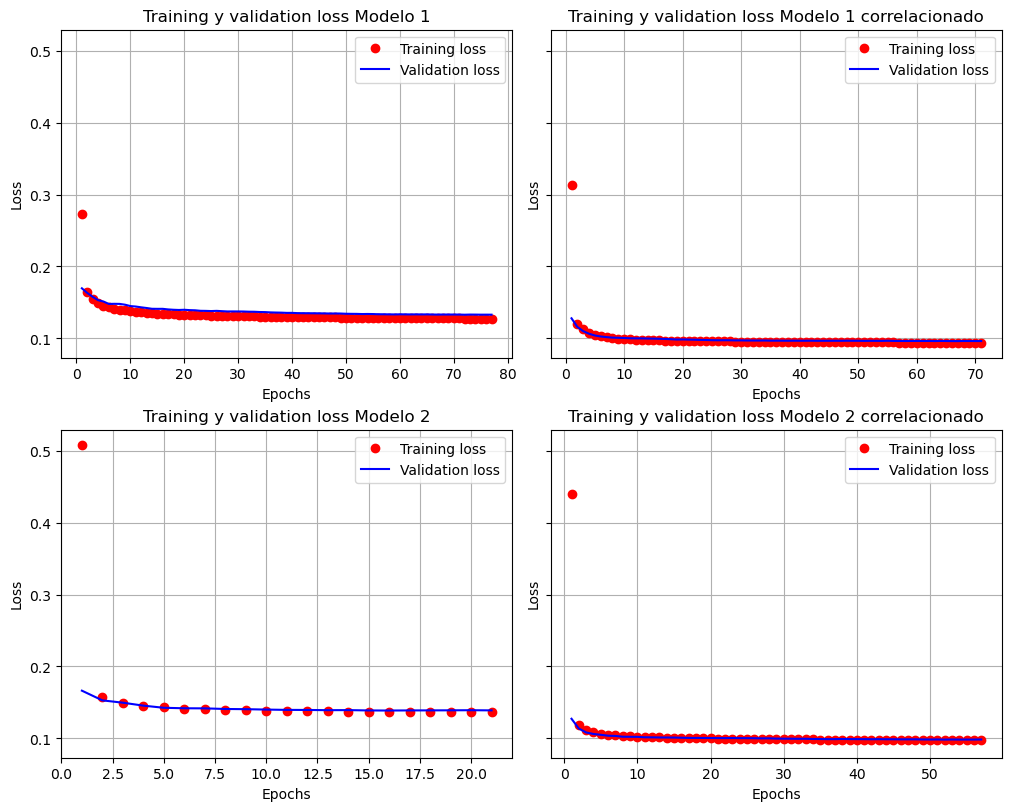

In [37]:
history_dicts = [history_1.history, history_2.history, history_1_corr.history, history_2_corr.history]
nombres = ['Modelo 1', 'Modelo 2', 'Modelo 1 correlacionado', 'Modelo 2 correlacionado' ]

fig, axis = plt.subplots(2, 2, figsize=(10,8), sharey='all', constrained_layout=1)
a, b = 0, 0
for i in range(len(history_dicts)):
  if a == 2 : a = 0; b = 1

  history_dict, nombre = history_dicts[i], nombres[i]
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)

  axis[a, b].plot(epochs, loss_values, "bo", label="Training loss", c='r')
  axis[a, b].plot(epochs, val_loss_values, "b", label="Validation loss")
  axis[a, b].set_title("Training y validation loss " + nombre)
  axis[a, b].set_xlabel("Epochs")
  axis[a, b].set_ylabel("Loss")
  axis[a, b].legend()
  axis[a, b].grid(True)

  a += 1
plt.show()

/tmp/ipykernel_48560/259789192.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  axis[a, b].plot(epochs, loss_values, "bo", label="Training mae", c='r')


<Figure size 640x480 with 0 Axes>

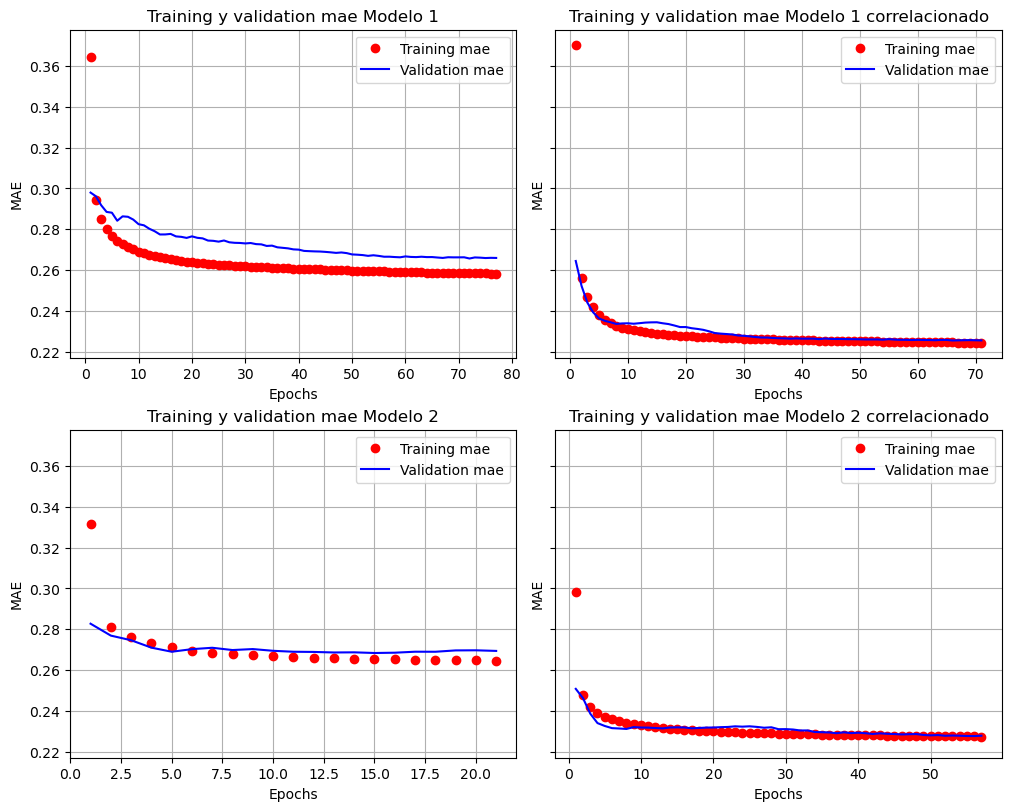

In [38]:
plt.clf()

fig, axis = plt.subplots(2, 2, figsize=(10,8), sharey='all', constrained_layout=1)
a, b = 0, 0
for i in range(len(history_dicts)):
  if a == 2 : a = 0; b = 1

  history_dict, nombre = history_dicts[i], nombres[i]
  loss_values = history_dict["mae"]
  val_loss_values = history_dict["val_mae"]
  epochs = range(1, len(loss_values) + 1)

  axis[a, b].plot(epochs, loss_values, "bo", label="Training mae", c='r')
  axis[a, b].plot(epochs, val_loss_values, "b", label="Validation mae")
  axis[a, b].set_title("Training y validation mae " + nombre)
  axis[a, b].set_xlabel("Epochs")
  axis[a, b].set_ylabel("MAE")
  axis[a, b].legend()
  axis[a, b].grid(True)

  a += 1
plt.show()

# Learning rates.

En las gráficas se observa que alrededor de las primeras 10 épocas se tiene un learning rate alto, después de estas épocas se tiene un learning rate normal, parece ser lineal.

In [43]:
modelos = [[model_1, final_features_base_test_scaled, 'Modelo 1'], [model_2, final_features_base_test_scaled, 'Modelo 2'],
           [model_1_corr, final_features_corr_test_scaled, 'Modelo 1 Correlacionado'], [model_2_corr, final_features_corr_test_scaled, 'Modelo 2 Correlacionado']]

for modelo in modelos :
  model, test, nombre = modelo[0], modelo[1], modelo[2]
  y_pred_full_scaled = model.predict(test).flatten()
  values_array_full = final_target_test
  output_dir = ''

  # Ensure shapes match for plotting
  if values_array_full.shape == y_pred_full_scaled.shape:
    number_of_bins = 55
    counts, xedges, yedges = np.histogram2d(values_array_full, y_pred_full_scaled, bins=number_of_bins)
    counts_mean = np.mean(counts)
    counts_std = np.std(counts)
    print(f"  2D Histogram Mean: {counts_mean:.4f}")
    print(f"  2D Histogram Standard Deviation: {counts_std:.4f}")

    plt.figure(figsize=(12, 10))
    plt.pcolormesh(xedges, yedges, counts.T, cmap='rainbow', norm=colors.LogNorm())
    min_val = min(np.min(values_array_full), np.min(y_pred_full_scaled))
    max_val = max(np.max(values_array_full), np.max(y_pred_full_scaled))
    plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--') # Line y=x

    plt.xlabel(r'$\log(E_{\mathrm{True}}/GeV)$', fontsize=15)
    plt.ylabel(r'$\log(E_{\mathrm{reco}}/GeV)$', fontsize=15)

    plt.xlim(min(2.5, min_val - 0.1), max(6.5, max_val + 0.1))
    plt.ylim(min(2.5, min_val - 0.1), max(6.5, max_val + 0.1))
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.colorbar(label='Counts')
    plt.title(f'True vs Predicted Energy (Full Filtered Dataset) {nombre}')
    # Save plot directly in output_dir
    plot2d_path = f'plot_MLP_validation_2Dhist{nombre}.png'
    plt.savefig(plot2d_path, bbox_inches='tight')
    print(f"2D histogram plot saved to {plot2d_path}")
    plt.close()
  else:
    print("Skipping 2D histogram plot.")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 765us/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 221.3895
2D histogram plot saved to plot_MLP_validation_2DhistModelo 1.png
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 963us/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 198.9510
2D histogram plot saved to plot_MLP_validation_2DhistModelo 2.png
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 821us/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 205.3153
2D histogram plot saved to plot_MLP_validation_2DhistModelo 1 Correlacionado.png
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 890us/step
  2D Histogram Mean: 66.1157
  2D Histogram Standard Deviation: 212.9824
2D histogram plot saved to plot_MLP_validation_2DhistModelo 2 Correlacionado.png


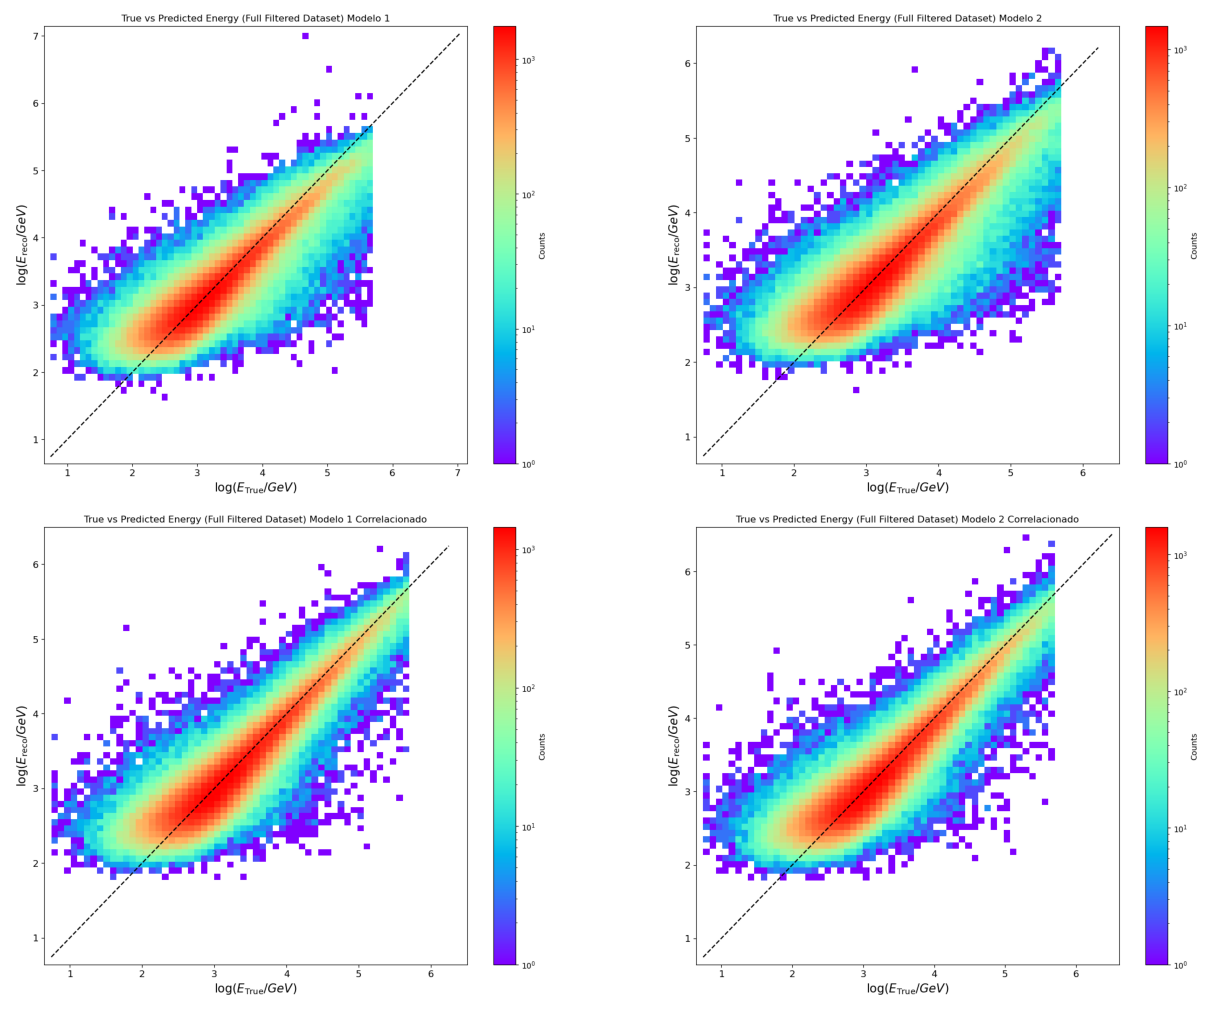

In [45]:
fig, axis = plt.subplots(2, 2, figsize=(13,10), sharey='all', constrained_layout=1)
contador = 0
for i in range(0,2):
  for j in range(0,2):
    nombre = modelos[contador][2]
    contador += 1
    im = plt.imread(f'plot_MLP_validation_2Dhist{nombre}.png')
    img = axis[i,j].imshow(im)
    axis[i,j].set_axis_off()
plt.savefig('Comparacion.png', bbox_inches='tight')
plt.show()

In [46]:
energy_bins = np.array([0.6, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.5, np.inf])
bin_centers = ( energy_bins [: -1] + energy_bins [1:]) / 2.0

In [47]:
from scipy.optimize import curve_fit
from scipy.stats import norm

In [48]:
def gauss_func_scipy(x , a , mu , sigma ):
  return a*np.exp(-(x-mu)**2/(2*sigma**2) )

In [49]:
def fit_gaussian_to_errors(error_data_for_bin , hist_bins =50):
  if error_data_for_bin is None or len ( error_data_for_bin ) < 20:
    return np.nan, np.nan

  counts, bin_edges = np.histogram(error_data_for_bin, bins = hist_bins, density = False )
  bin_centers_hist = (bin_edges[: -1] + bin_edges[1:])/2.0

  non_zero_indices = counts > 0
  if not np.any(non_zero_indices):
    return np.nan, np.nan

  counts_fit = counts[non_zero_indices]
  bin_centers_fit = bin_centers_hist[non_zero_indices]

  try:
    initial_amplitude = np.max(counts_fit)
    initial_mu = np.mean(error_data_for_bin)
    initial_sigma = np.std(error_data_for_bin)

    if initial_sigma == 0 :
      initial_sigma = 1e-2

    popt , pcov = curve_fit(gauss_func_scipy , bin_centers_fit, counts_fit, p0=[ initial_amplitude , initial_mu, initial_sigma ], maxfev =10000)

    mu_fit = popt[1]
    sigma_fit = abs(popt[2])
    return mu_fit, sigma_fit

  except RuntimeError:
    valid_data = error_data_for_bin [~np.isnan(error_data_for_bin) & ~np.isinf( error_data_for_bin )]
    if len ( valid_data ) > 1:
      return np.mean(valid_data), np.std(valid_data)
    else:
      return np.nan, np.nan


In [50]:
def grafi(modelo, test):
  global final_target_test
  energia_simulacion = final_target_test
  #Comparacion de modelos
  try :
    energia_modelo = modelo.predict(test)
    energia_modelo = energia_modelo.flatten()
  except AttributeError:
    energia_modelo = modelo

  errors_all = energia_modelo - energia_simulacion
  errors_per_bin = []
  events_in_bin_counts = []

  for i in range (len(energy_bins) - 1) :
    low_e = energy_bins[i]
    high_e = energy_bins[i + 1]

    # Mascara para seleccionar eventos en el bin actual
    mask = ( energia_simulacion >= low_e ) & ( energia_simulacion < high_e )

    errors_in_this_bin = errors_all[mask]
    errors_per_bin.append(errors_in_this_bin)
    events_in_bin_counts.append(len( errors_in_this_bin ) )

    #print(f"Bin [{ low_e :.2f} , { high_e :.2f}): { len ( errors_in_this_bin )} eventos ]")

  bias_values = []
  resolution_values = []
  bin_centers_plot = []

  for i in range(len(energy_bins) -1):
    errors_in_this_bin = errors_per_bin[i]
    mu, sigma = fit_gaussian_to_errors(errors_in_this_bin)

    if not ( np.isnan(mu) or np.isnan(sigma)):
      bias_values.append(mu)
      resolution_values.append(sigma)
      bin_centers_plot.append(bin_centers[i])
  return bias_values, resolution_values, bin_centers_plot

In [52]:
energia_modelo_nn = df.iloc[final_test_indices, indice_modeloAlterno].values
energia_modelo_gp = df.iloc[final_test_indices, indice_modelo_GP].values

In [57]:
modelos = [[model_1, final_features_base_test_scaled, 'Modelo 1'], [model_2, final_features_base_test_scaled, 'Modelo 2'],
           [model_1_corr, final_features_corr_test_scaled, 'Modelo 1 Correlacionado'], [model_2_corr, final_features_corr_test_scaled, 'Modelo 2 Correlacionado'],
           [energia_modelo_nn, None, 'Modelo NN'], [energia_modelo_gp, None, 'Modelo GP']]
bias_values_all = []
resolution_values_all = []
bin_centers_plot_all = []

for modelo in modelos:
  a = grafi(modelo[0], modelo[1])
  bias_values_all.append(a[0])
  resolution_values_all.append(a[1])
  bin_centers_plot_all.append(a[2])

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 712us/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 808us/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 746us/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 5s 803us/step


<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_48560/1455881196.py:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel('Bias ($\mu$ del ajuste Gaussiano )')
/tmp/ipykernel_48560/1455881196.py:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean 

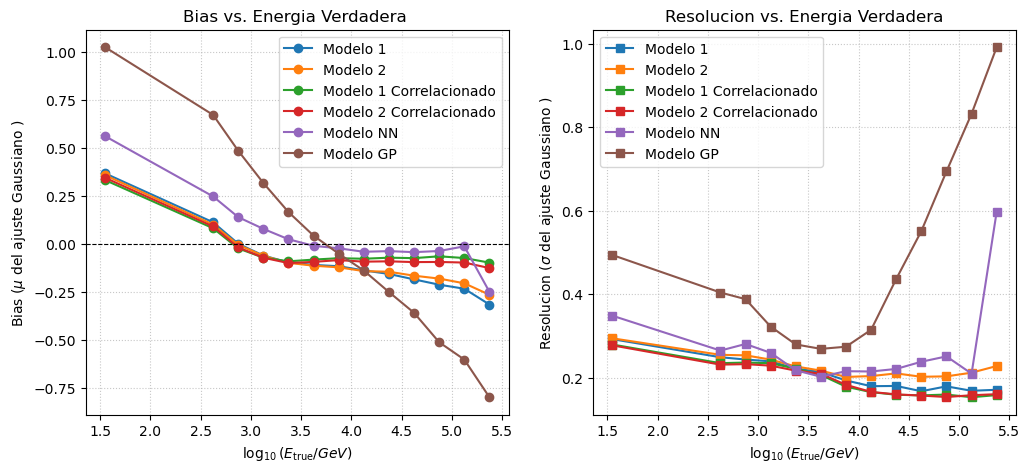

In [59]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(0, len(bias_values_all)):
  bias_values = bias_values_all[i]
  bin_centers_plot = bin_centers_plot_all[i]
  plt.plot(bin_centers_plot , bias_values, 'o-' , label=modelos[i][2])

plt.axhline(0, color ='black', linestyle ='--', linewidth =0.8)
plt.xlabel(r'$\log_{10}( E_{\mathrm{true}}/ GeV )$')
plt.ylabel('Bias ($\mu$ del ajuste Gaussiano )')
plt.title('Bias vs. Energia Verdadera ')
plt.grid(True , linestyle =':', alpha =0.7)
plt.legend()

plt.subplot(1, 2, 2)
for i in range(0, len(resolution_values_all)):
  resolution_values = resolution_values_all[i]
  bin_centers_plot = bin_centers_plot_all[i]
  plt.plot(bin_centers_plot , resolution_values, 's-', label =modelos[i][2])

plt.xlabel(r'$\log_{10}( E_{\mathrm{true}}/ GeV )$')
plt.ylabel('Resolucion ($\sigma$ del ajuste Gaussiano )')
plt.title('Resolucion vs. Energia Verdadera')
plt.grid( True , linestyle =':', alpha =0.7)
plt.legend()
plt.savefig('Comparacion_final.png', bbox_inches='tight')
plt.show()

### Bias (Sesgo): 
Indica una desviación sistemática promedio de la energía reconstruida respecto a la verdadera. Un bias positivo significa que, en promedio, el algoritmo sobreestima la energía, mientras que un bias negativo indica una subestimación. Idealmente, el bias debería ser cero en todo el rango de energías.
### Resolución de Energía:
Mide la dispersión o el ancho de la distribución de las energías reconstruidas alrededor de la energía verdadera (o del error de reconstrucción alrededor de cero). Una mejor resolución implica una distribución más estrecha, lo que significa menos incertidumbre en la energía reconstruida.

# Uso de transfer learning.

La red no es muy compleja, por lo que no se necesita de una preentrenada.

# Uso de data augmentation.

La cantidad de datos fue suficiente. La diferencia entre el rendimiento de la red entrenada con 500 mil y 1 millón no fue significativa, aunque he de mencionar que había 20.5 millones de datos disponibles, pero por limitaciones computacionales y de red no se pudieron usar.


# Discusión y conclusiones

El modelo construido es mejor a más bajas energías (hasta alrededor de 1000 GeV) y equiparable a altas energías.
Aunque parece ser mejor a las más altas energías (100 000 GeV), la verdad es que el modelo NN mejora mucho aquí con más datos.
No parece que un modelo más robusto sea la solución para mejorar el modelo propuesto aquí en altas energías, sino la cantidad de datos en estas energías. Como se observa en las gráficas, con la cantidad de datos suficientes —como a más bajas energías— el modelo es mejor.

El modelo solo se llegó a entrenar con, a lo más, 5 millones de datos (en la presentación se usó 1 millón). Con esta cantidad de datos, NN sigue siendo mejor en cierta región de altas energías, pero se cree que con la cantidad de datos suficiente el modelo puede superar a NN en todos los rangos de energía.

# Gracias por su atención !

Referencias: \
[1] Marinelli, S. S., & Goodman, J. A. (2017). Measuring High-Energy Spectra with HAWC. Presented on behalf of the HAWC Collaboration. Michigan State University & University of Maryland \
[2] Mirón Enríquez, P. E. (2025). Análisis introductorio del estimador de energía rec.logNNEnergy de HAWC (Documentación de proyecto). Basado en S. S. Marinelli, J. A. Goodman, ICRC 2017, y otros. \
[3] Malone, K.A. (2018) A Survey of the Highest-Energy Astrophysical Sources with the HAWC Observatory. PhD Thesis. Penn State U., Penn State U.